# Question Answering Success Analysis

In this notebook the the performance of the boardgame rulebook question answering system will be analyzed. It loads question-answer results, computes success metrics, and visualizes the results with graphs.

In [8]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

## Load Question Answering Results Data

Load the results data (CSV or JSON) containing ground truth answers and predicted answers. Update the file path as needed.

In [45]:
# Example: Load results from a CSV or JSON file
# Update the file path as needed
results_path = '../data/processed/qa_results.csv'  # or .json

# Try loading CSV, fallback to JSON
try:
    df = pd.read_csv(results_path)
except Exception:
    df = pd.read_json(results_path)

df.head()

,question,ground_truth,predicted,score,page,section,chunk_index,best_chunk_rank
0,When do I increase my radiation?,Each time a Stalker slides their Turn token (a...,This can be reduced by your Armor's Cap Radiat...,0.673800,44,) increase your Radiation,NaN,NaN
1,How do I win the mission?,Each Mission has a main Objective card which s...,Plan your Actions accordingly! Missions are va...,0.563674,18,Objective,NaN,NaN
2,How many players can play this game?,This game can be played by 1-4 players.,Too many guys to divide the loot. Real profess...,0.404331,38,"During a Mission, Stalkers can accumulate Radi...",NaN,NaN
3,How does movement work?,"On your turn, when you use the Move action, yo...","After an Entity finishes Movement, if they Cov...",0.692728,44,) increase your Radiation,NaN,NaN
4,How do I perform an attack action?,Choose an Attack Action and a valid Target. - ...,These effects may be used before or after the ...,0.663407,27,Coupon value,NaN,NaN


## Preprocess and Explore Data

Clean and preprocess the data, handle missing values, and display basic statistics about the dataset.

In [46]:
# Drop rows with missing values in essential columns only
clean_df = df.dropna(subset=['question', 'ground_truth', 'predicted'])

# Show basic statistics
print('Number of questions:', len(clean_df))
print('Columns:', clean_df.columns.tolist())
clean_df.describe(include='all')

Number of questions: 39
Columns: ['question', 'ground_truth', 'predicted', 'score', 'page', 'section', 'chunk_index', 'best_chunk_rank']


,question,ground_truth,predicted,score,page,section,chunk_index,best_chunk_rank
count,39,39,39,39.000000,39.000000,39,0.0,0.0
unique,39,38,37,NaN,NaN,18,NaN,NaN
top,When do I increase my radiation?,"When any Stalker dies, you fail your current M...",They contain various numbers of results which ...,NaN,NaN,"During a Mission, Stalkers can accumulate Radi...",NaN,NaN
freq,1,2,2,NaN,NaN,7,NaN,NaN
mean,NaN,NaN,NaN,0.614866,28.692308,NaN,NaN,NaN
std,NaN,NaN,NaN,0.110769,10.167424,NaN,NaN,NaN
min,NaN,NaN,NaN,0.384887,4.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.543610,20.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.625432,31.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,0.676695,36.000000,NaN,NaN,NaN


## Calculate Success Metrics Using Similarity

Compute and visualize fuzzy string similarity (token set ratio) for the question answering results. This provides a more realistic measure of model performance for free-form answers.

C:\Users\I544554\AppData\Local\Temp\ipykernel_21840\977814103.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['similarity'] = similarities
C:\Users\I544554\AppData\Local\Temp\ipykernel_21840\977814103.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['correct'] = clean_df['similarity'] >= threshold


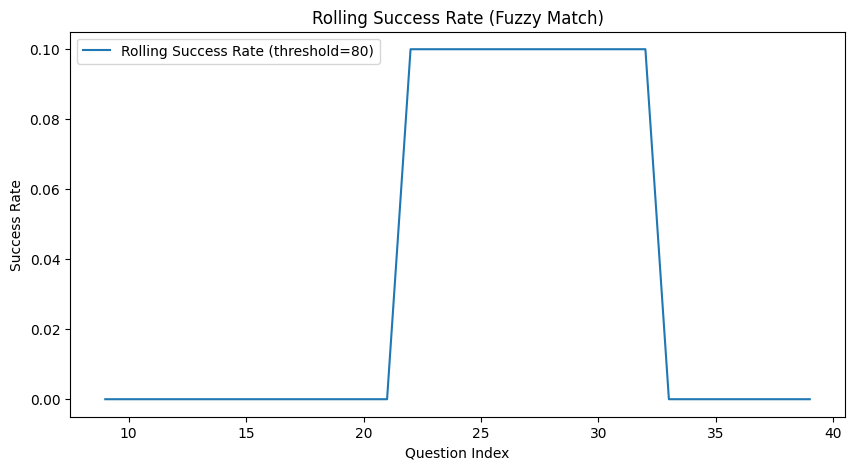

In [47]:
# Define threshold for fuzzy match success
threshold = 80
if 'similarity' not in clean_df.columns:
    try:
        from rapidfuzz import fuzz
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
        from rapidfuzz import fuzz
    similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(clean_df['ground_truth'], clean_df['predicted'])]
    clean_df['similarity'] = similarities
clean_df['correct'] = clean_df['similarity'] >= threshold

# Rolling success rate
window = 10
rolling_success = clean_df['correct'].rolling(window).mean()
plt.figure(figsize=(10,5))
plt.plot(rolling_success, label=f'Rolling Success Rate (threshold={threshold})')
plt.xlabel('Question Index')
plt.ylabel('Success Rate')
plt.title('Rolling Success Rate (Fuzzy Match)')
plt.legend()
plt.show()

## Fuzzy String Similarity Analysis

Since exact string match metrics are too strict for free-form answers, we use fuzzy string similarity to better gauge answer quality.

Mean similarity: 39.85


C:\Users\I544554\AppData\Local\Temp\ipykernel_21840\877489707.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['similarity'] = similarities


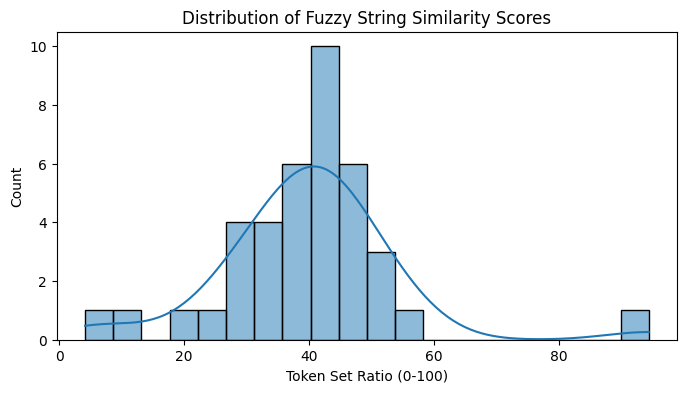

In [48]:
# Install rapidfuzz if not already installed
try:
    from rapidfuzz import fuzz
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
    from rapidfuzz import fuzz

# Use ground_truth and predicted columns from clean_df
y_true = clean_df['ground_truth']
y_pred = clean_df['predicted']

# Compute similarity scores
similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(y_true, y_pred)]
clean_df['similarity'] = similarities

print(f'Mean similarity: {np.mean(similarities):.2f}')
plt.figure(figsize=(8,4))
sns.histplot(similarities, bins=20, kde=True)
plt.title('Distribution of Fuzzy String Similarity Scores')
plt.xlabel('Token Set Ratio (0-100)')
plt.ylabel('Count')
plt.show()

## Fuzzy Match Confusion Matrix

We treat predictions as correct if their similarity is above the threshold, and plot a confusion matrix.

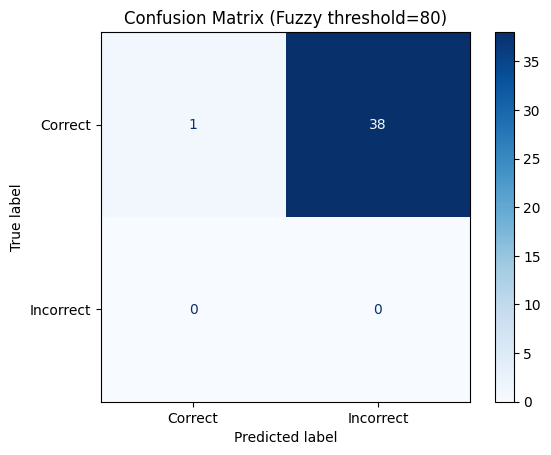

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True: all answers are expected to be correct (since each row is a QA pair)
y_true_bin = np.ones(len(clean_df), dtype=int)
y_pred_bin = clean_df['correct'].astype(int)

cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[1,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Correct', 'Incorrect'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Fuzzy threshold={threshold})')
plt.show()

## Visualize Success Rate Over Time (Fuzzy Match)

We define a prediction as 'correct' if its similarity to the ground truth is above a threshold (e.g., 80).

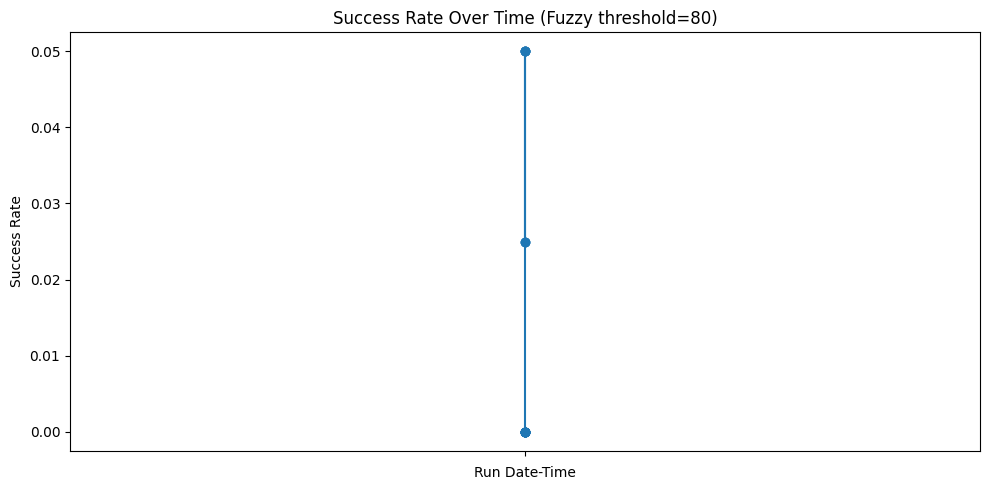

In [50]:
import glob
import re

# Find all archived qa_results files
archive_files = sorted(glob.glob('../data/processed/archive/qa_results_*.csv'))

# Extract datetime from filename for sorting
pattern = re.compile(r'qa_results_(\d{8}_\d{6})_\d+s\\.csv$|qa_results_(\d{8}_\d{6})_\d+s\.csv$')

def extract_dt(fname):
    match = pattern.search(fname)
    if match:
        return match.group(1) or match.group(2)
    return ''

archive_files = sorted(archive_files, key=extract_dt)

success_rates = []
datetimes = []
threshold = 80

for f in archive_files:
    df = pd.read_csv(f)
    if 'similarity' not in df.columns:
        # Compute similarity if not present
        try:
            from rapidfuzz import fuzz
        except ImportError:
            import sys, subprocess
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
            from rapidfuzz import fuzz
        similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(df['ground_truth'], df['predicted'])]
        df['similarity'] = similarities
    correct = (df['similarity'] >= threshold).mean()
    success_rates.append(correct)
    datetimes.append(extract_dt(f))

plt.figure(figsize=(10,5))
plt.plot(datetimes, success_rates, marker='o')
plt.xticks(rotation=45)
plt.xlabel('Run Date-Time')
plt.ylabel('Success Rate')
plt.title(f'Success Rate Over Time (Fuzzy threshold={threshold})')
plt.tight_layout()
plt.show()

## Compare Different Hybrid Search Weights

Compare the performance of different vector vs keyword weight configurations to find the optimal balance.


HYBRID SEARCH WEIGHT COMPARISON
                Weight Config  Mean Similarity  Success Rate  Success Count  Total
w30 (30% vector, 70% keyword)        38.648675         0.025              1     40
w50 (50% vector, 50% keyword)        39.420531         0.025              1     40
w70 (70% vector, 30% keyword)        40.452632         0.050              2     40
w90 (90% vector, 10% keyword)        38.887290         0.025              1     40


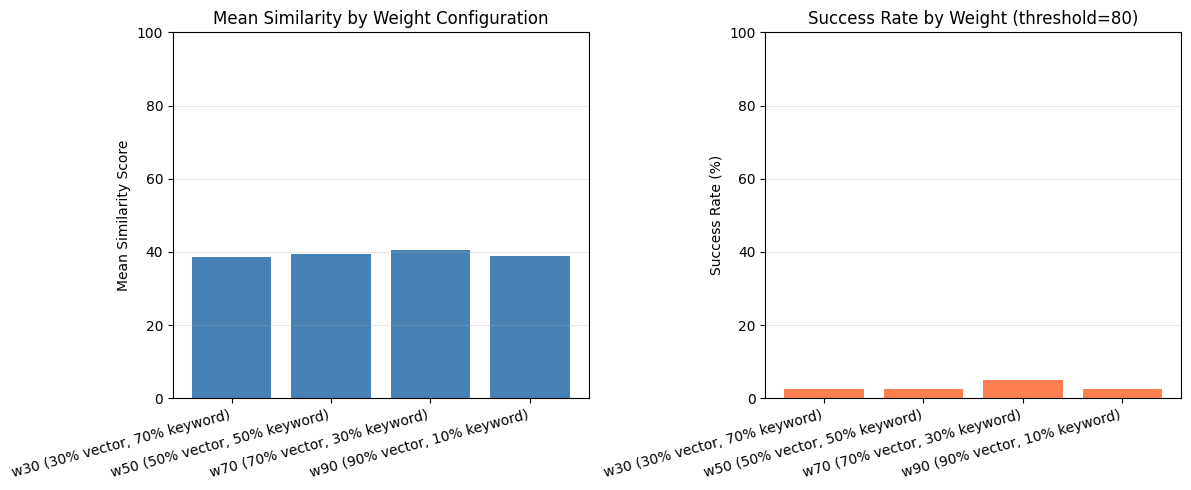

In [51]:
import glob
import pandas as pd
from rapidfuzz import fuzz
import numpy as np

# Find weight test files
weight_files = {
    'w30 (30% vector, 70% keyword)': '../data/processed/archive/qa_results_2025-12-24_12-34-40_57s_w30.csv',
    'w50 (50% vector, 50% keyword)': '../data/processed/archive/qa_results_2025-12-24_12-36-43_56s_w50.csv',
    'w70 (70% vector, 30% keyword)': '../data/processed/archive/qa_results_2025-12-24_12-30-59_54s.csv',
    'w90 (90% vector, 10% keyword)': '../data/processed/archive/qa_results_2025-12-24_12-38-25_55s_w90.csv',
}

threshold = 80
comparison_results = []

for weight_label, filepath in weight_files.items():
    try:
        df = pd.read_csv(filepath)
        
        # Calculate similarities if not present
        if 'similarity' not in df.columns:
            similarities = [fuzz.token_set_ratio(str(gt), str(pred)) 
                          for gt, pred in zip(df['ground_truth'], df['predicted'])]
            df['similarity'] = similarities
        
        # Calculate metrics
        mean_sim = df['similarity'].mean()
        success_rate = (df['similarity'] >= threshold).mean()
        
        comparison_results.append({
            'Weight Config': weight_label,
            'Mean Similarity': mean_sim,
            'Success Rate': success_rate,
            'Success Count': (df['similarity'] >= threshold).sum(),
            'Total': len(df)
        })
    except FileNotFoundError:
        print(f"File not found: {filepath}")

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results)
print("\n" + "="*70)
print("HYBRID SEARCH WEIGHT COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(comparison_df)), comparison_df['Mean Similarity'], color='steelblue')
plt.xticks(range(len(comparison_df)), comparison_df['Weight Config'], rotation=15, ha='right')
plt.ylabel('Mean Similarity Score')
plt.title('Mean Similarity by Weight Configuration')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(len(comparison_df)), comparison_df['Success Rate'] * 100, color='coral')
plt.xticks(range(len(comparison_df)), comparison_df['Weight Config'], rotation=15, ha='right')
plt.ylabel('Success Rate (%)')
plt.title(f'Success Rate by Weight (threshold={threshold})')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()